# Latest GW Player Picker Dashboard

Use this notebook to shortlist players by position, inspect predicted points, and generate plots you can share with your league group.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from latest_gw_tools import load_latest_outputs, load_gw_outputs
from other_funcs import get_best_11, get_best_11_noadj, get_owner_dict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [2]:
# Leave TARGET_GW as None to auto-load latest available GW output.
TARGET_GW = None
TOP_N = 20
BACKTEST_YEAR = 26
EXPORT_FIGURES = False
FIG_DIR = Path('figures')

if EXPORT_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
if TARGET_GW is None:
    latest_gw, pred_simple, pred_full, fixture_difficulty = load_latest_outputs()
else:
    latest_gw = TARGET_GW
    pred_simple, pred_full, fixture_difficulty = load_gw_outputs(TARGET_GW)

print(f'Loaded GW: {latest_gw}')
print(f'Players in simple output: {len(pred_simple):,}')
print(f'Players in full output: {len(pred_full):,}')

Loaded GW: 38
Players in simple output: 842
Players in full output: 842


In [4]:
df = pred_simple.copy()
if 'predicted_points_adj' not in df.columns:
    df['predicted_points_adj'] = df['predicted_points']

owner_dict = get_owner_dict()
owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}
df['owner_name'] = df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

# Combine duplicate player rows (e.g., double gameweeks) into one row per player/team/position/owner.
group_cols = ['full_name', 'team', 'position', 'owner_name']
for col in ['predicted_points', 'predicted_points_adj', 'fixture_diff_index']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

agg_dict = {
    'predicted_points': 'sum',
    'predicted_points_adj': 'sum',
}
if 'fixture_diff_index' in df.columns:
    agg_dict['fixture_diff_index'] = 'mean'

df = (
    df.groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

rank_col = 'predicted_points_adj'
df_sorted = df.sort_values(rank_col, ascending=False).reset_index(drop=True)
df_sorted.head(10)

,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,erling_haaland,Man City,FWD,Doug,5.432718,10.027148,1.845696
1,william_osula,Newcastle,FWD,Will,3.722895,7.445791,2.000000
2,jeremy_doku,Man City,MID,Lucas,4.878831,7.133764,1.462187
3,gabriel_dos_santos_magalhaes,Arsenal,DEF,Will,3.923690,6.537303,1.666111
4,william_saliba,Arsenal,DEF,Lucas,3.406269,5.675221,1.666111
5,antoine_semenyo,Man City,MID,Will,3.824796,5.592568,1.462187
6,danny_welbeck,Brighton,FWD,Will,2.751983,5.503966,2.000000
7,david_raya_martin,Arsenal,GK,Dave,4.030086,5.476783,1.358974
8,dominik_szoboszlai,Liverpool,MID,Dave,4.366548,5.331112,1.220898
9,bukayo_saka,Arsenal,MID,Will,4.177743,4.994774,1.195568


In [5]:
## Position Shortlists

In [6]:
show_cols = ['full_name', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
position_lists = {}

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_df = (
        df_sorted
        .query('position == @pos')
        .loc[:, show_cols]
        .head(TOP_N)
        .reset_index(drop=True)
    )
    position_lists[pos] = pos_df
    print(f'\nTop {TOP_N} {pos}')
    display(pos_df)


Top 20 GK


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,david_raya_martin,Arsenal,Dave,4.030086,5.476783,1.358974
1,robin_roefs,Sunderland,Rory,2.901001,4.165540,1.435897
2,karl_darlow,Leeds,Free Agent,3.003800,4.031857,1.342252
3,gianluigi_donnarumma,Man City,Lucas,3.815688,3.516501,0.921590
4,mads_hermansen,West Ham,Lucas,2.644344,3.323363,1.256782
5,bernd_leno,Fulham,Doug,3.152972,3.247878,1.030100
6,matz_sels,Nott'm Forest,Free Agent,2.922774,3.072660,1.051282
7,nick_pope,Newcastle,Free Agent,2.945845,3.014812,1.023411
8,senne_lammens,Man Utd,Rory,3.131950,2.892194,0.923449
9,bart_verbruggen,Brighton,Will,3.084774,2.888752,0.936455



Top 20 DEF


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,gabriel_dos_santos_magalhaes,Arsenal,Will,3.923690,6.537303,1.666111
1,william_saliba,Arsenal,Lucas,3.406269,5.675221,1.666111
2,marc_guehi,Man City,Marcus,3.259588,4.298865,1.318837
3,riccardo_calafiori,Arsenal,Free Agent,2.334076,3.888829,1.666111
4,matheus_nunes,Man City,Lucas,2.665044,3.514759,1.318837
5,virgil_van_dijk,Liverpool,Marcus,3.168791,3.510723,1.107906
6,nordi_mukiele,Sunderland,Free Agent,2.718155,3.472869,1.277657
7,nico_o'reilly,Man City,Doug,2.578357,3.400433,1.318837
8,abdukodir_khusanov,Man City,Doug,2.566832,3.385233,1.318837
9,james_tarkowski,Everton,Marcus,3.253281,3.319066,1.020221



Top 20 MID


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,jeremy_doku,Man City,Lucas,4.878831,7.133764,1.462187
1,antoine_semenyo,Man City,Will,3.824796,5.592568,1.462187
2,dominik_szoboszlai,Liverpool,Dave,4.366548,5.331112,1.220898
3,bukayo_saka,Arsenal,Will,4.177743,4.994774,1.195568
4,bruno_borges_fernandes,Man Utd,Will,5.494335,4.811245,0.875674
5,pascal_gross,Brighton,Doug,4.137842,4.692665,1.134085
6,jack_hinshelwood,Brighton,Will,4.084694,4.632391,1.134085
7,phil_foden,Man City,Free Agent,3.140207,4.591571,1.462187
8,rayan_cherki,Man City,Lucas,3.068020,4.486019,1.462187
9,bernardo_mota_veiga_de_carvalho_e_silva,Man City,Doug,3.035215,4.438052,1.462187



Top 20 FWD


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,erling_haaland,Man City,Doug,5.432718,10.027148,1.845696
1,william_osula,Newcastle,Will,3.722895,7.445791,2.000000
2,danny_welbeck,Brighton,Will,2.751983,5.503966,2.000000
3,nick_woltemade,Newcastle,Free Agent,2.487021,4.974042,2.000000
4,viktor_gyokeres,Arsenal,Doug,3.435033,4.848859,1.411590
5,ollie_watkins,Aston Villa,Rory,4.190748,4.480128,1.069052
6,igor_thiago_nascimento_rodrigues,Brentford,Marcus,3.643561,4.187597,1.149314
7,brian_brobbey,Sunderland,Doug,3.164392,3.965536,1.253175
8,kai_havertz,Arsenal,Free Agent,2.506189,3.537712,1.411590
9,igor_jesus_maciel_da_cruz,Nott'm Forest,Marcus,3.609686,3.510378,0.972488


In [7]:
show_cols = ['full_name', 'team', 'position', 'owner_name', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
positions = ['GK', 'DEF', 'MID', 'FWD']

for pos in positions:
    doug_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Doug"')
        .loc[:, show_cols]
    )

    free_agent_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Free Agent"')
        .loc[:, show_cols]
        .head(20)
    )

    combined_pos = pd.concat([doug_pos, free_agent_pos], ignore_index=True)

    print(f'\n{pos}: Doug + Top Free Agents')
    display(combined_pos)



GK: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,bernd_leno,Fulham,GK,Doug,3.152972,3.247878,1.030100
1,jordan_pickford,Everton,GK,Doug,2.928035,1.932438,0.659978
2,karl_darlow,Leeds,GK,Free Agent,3.003800,4.031857,1.342252
3,matz_sels,Nott'm Forest,GK,Free Agent,2.922774,3.072660,1.051282
4,nick_pope,Newcastle,GK,Free Agent,2.945845,3.014812,1.023411
5,dorde_petrovic,Bournemouth,GK,Free Agent,3.109954,2.237410,0.719435
6,emiliano_martinez_romero,Aston Villa,GK,Free Agent,3.132733,1.566367,0.500000
7,antonin_kinsky,Spurs,GK,Free Agent,2.595353,1.297676,0.500000
8,martin_dubravka,Burnley,GK,Free Agent,1.497830,1.200045,0.801189
9,jose_malheiro_de_sa,Wolves,GK,Free Agent,1.414538,1.182724,0.836120



DEF: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,nico_o'reilly,Man City,DEF,Doug,2.578357,3.400433,1.318837
1,abdukodir_khusanov,Man City,DEF,Doug,2.566832,3.385233,1.318837
2,james_hill,Bournemouth,DEF,Doug,2.699114,2.487195,0.921486
3,timothy_castagne,Fulham,DEF,Doug,2.571741,2.014072,0.783155
4,keane_lewis_potter,Brentford,DEF,Doug,2.643698,1.982190,0.749779
5,riccardo_calafiori,Arsenal,DEF,Free Agent,2.334076,3.888829,1.666111
6,nordi_mukiele,Sunderland,DEF,Free Agent,2.718155,3.472869,1.277657
7,myles_lewis_skelly,Arsenal,DEF,Free Agent,1.986858,3.310325,1.666111
8,benjamin_white,Arsenal,DEF,Free Agent,1.935492,3.224744,1.666111
9,marcos_senesi_baron,Bournemouth,DEF,Free Agent,3.429610,3.160337,0.921486



MID: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,pascal_gross,Brighton,MID,Doug,4.137842,4.692665,1.134085
1,bernardo_mota_veiga_de_carvalho_e_silva,Man City,MID,Doug,3.035215,4.438052,1.462187
2,cody_gakpo,Liverpool,MID,Doug,3.177734,3.879690,1.220898
3,eberechi_eze,Arsenal,MID,Doug,3.172653,3.793121,1.195568
4,morgan_gibbs_white,Nott'm Forest,MID,Doug,3.499655,3.635734,1.038884
5,phil_foden,Man City,MID,Free Agent,3.140207,4.591571,1.462187
6,omar_marmoush,Man City,MID,Free Agent,2.701467,3.950050,1.462187
7,alexis_mac_allister,Liverpool,MID,Free Agent,3.221205,3.932765,1.220898
8,ethan_ampadu,Leeds,MID,Free Agent,2.982138,3.890284,1.304528
9,elliot_anderson,Nott'm Forest,MID,Free Agent,3.631419,3.772622,1.038884



FWD: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,erling_haaland,Man City,FWD,Doug,5.432718,10.027148,1.845696
1,viktor_gyokeres,Arsenal,FWD,Doug,3.435033,4.848859,1.411590
2,brian_brobbey,Sunderland,FWD,Doug,3.164392,3.965536,1.253175
3,nick_woltemade,Newcastle,FWD,Free Agent,2.487021,4.974042,2.000000
4,kai_havertz,Arsenal,FWD,Free Agent,2.506189,3.537712,1.411590
5,yoane_wissa,Newcastle,FWD,Free Agent,1.515785,3.031570,2.000000
6,thierno_barry,Everton,FWD,Free Agent,2.328273,2.768190,1.188945
7,taiwo_awoniyi,Nott'm Forest,FWD,Free Agent,2.842133,2.763941,0.972488
8,mateus_mane,Wolves,FWD,Free Agent,3.822151,2.679185,0.700963
9,francisco_evanilson_de_lima_barbosa,Bournemouth,FWD,Free Agent,3.130405,2.463187,0.786859


In [8]:
# A compact shortlist view you can screenshot/share.
shortlist = pd.concat(
    [
        position_lists[pos].assign(position=pos)
        for pos in ['GK', 'DEF', 'MID', 'FWD']
    ],
    ignore_index=True,
)

shortlist = shortlist[[
    'position', 'full_name', 'team', 'owner_name',
    'predicted_points', 'predicted_points_adj', 'fixture_diff_index'
 ]]
shortlist.head(40)

,position,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,GK,david_raya_martin,Arsenal,Dave,4.030086,5.476783,1.358974
1,GK,robin_roefs,Sunderland,Rory,2.901001,4.165540,1.435897
2,GK,karl_darlow,Leeds,Free Agent,3.003800,4.031857,1.342252
3,GK,gianluigi_donnarumma,Man City,Lucas,3.815688,3.516501,0.921590
4,GK,mads_hermansen,West Ham,Lucas,2.644344,3.323363,1.256782
5,GK,bernd_leno,Fulham,Doug,3.152972,3.247878,1.030100
6,GK,matz_sels,Nott'm Forest,Free Agent,2.922774,3.072660,1.051282
7,GK,nick_pope,Newcastle,Free Agent,2.945845,3.014812,1.023411
8,GK,senne_lammens,Man Utd,Rory,3.131950,2.892194,0.923449
9,GK,bart_verbruggen,Brighton,Will,3.084774,2.888752,0.936455


In [9]:
## Team Selection Helpers

In [10]:
formation_adj, best_11_adj = get_best_11(df_sorted)
formation_raw, best_11_raw = get_best_11_noadj(df_sorted)

print(f'Best XI (adj) formation: {formation_adj}')
display(best_11_adj[['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj']])

print(f'Best XI (raw) formation: {formation_raw}')
display(best_11_raw[['full_name', 'position', 'team', 'owner_name', 'predicted_points']])

Best XI (adj) formation: {'GK': 1, 'DEF': 3, 'MID': 4, 'FWD': 3}


,full_name,position,team,owner_name,predicted_points,predicted_points_adj
8,erling_haaland,FWD,Man City,Doug,5.432718,10.027148
9,william_osula,FWD,Newcastle,Will,3.722895,7.445791
4,jeremy_doku,MID,Man City,Lucas,4.878831,7.133764
1,gabriel_dos_santos_magalhaes,DEF,Arsenal,Will,3.923690,6.537303
2,william_saliba,DEF,Arsenal,Lucas,3.406269,5.675221
5,antoine_semenyo,MID,Man City,Will,3.824796,5.592568
10,danny_welbeck,FWD,Brighton,Will,2.751983,5.503966
0,david_raya_martin,GK,Arsenal,Dave,4.030086,5.476783
6,dominik_szoboszlai,MID,Liverpool,Dave,4.366548,5.331112
7,bukayo_saka,MID,Arsenal,Will,4.177743,4.994774


Best XI (raw) formation: {'GK': 1, 'DEF': 3, 'MID': 5, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points
8,bruno_borges_fernandes,MID,Man Utd,Will,5.494335
9,erling_haaland,FWD,Man City,Doug,5.432718
4,jeremy_doku,MID,Man City,Lucas,4.878831
6,dominik_szoboszlai,MID,Liverpool,Dave,4.366548
7,bukayo_saka,MID,Arsenal,Will,4.177743
0,david_raya_martin,GK,Arsenal,Dave,4.030086
1,gabriel_dos_santos_magalhaes,DEF,Arsenal,Will,3.923690
5,antoine_semenyo,MID,Man City,Will,3.824796
10,william_osula,FWD,Newcastle,Will,3.722895
2,william_saliba,DEF,Arsenal,Lucas,3.406269


In [11]:
doug_pool = df_sorted.query('owner_name == "Doug"').copy()
doug_formation, doug_best_11 = get_best_11(doug_pool)

print(f"Doug Best XI formation: {doug_formation['DEF']}-{doug_formation['MID']}-{doug_formation['FWD']}")
display(
    doug_best_11[
        ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
    ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
)

bench_key_cols = ['full_name', 'team', 'position']
bench_keys = set(
    tuple(row) for row in doug_best_11[bench_key_cols].drop_duplicates().itertuples(index=False, name=None)
)
bench_players = (
    doug_pool[
        ~doug_pool[bench_key_cols].apply(tuple, axis=1).isin(bench_keys)
    ][['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']]
    .sort_values('predicted_points_adj', ascending=False)
    .reset_index(drop=True)
)

print('Doug Bench Players:')
display(bench_players)

Doug Best XI formation: 3-4-3


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,nico_o'reilly,DEF,Man City,2.578357,3.400433,1.318837
1,abdukodir_khusanov,DEF,Man City,2.566832,3.385233,1.318837
2,james_hill,DEF,Bournemouth,2.699114,2.487195,0.921486
3,erling_haaland,FWD,Man City,5.432718,10.027148,1.845696
4,viktor_gyokeres,FWD,Arsenal,3.435033,4.848859,1.411590
5,brian_brobbey,FWD,Sunderland,3.164392,3.965536,1.253175
6,bernd_leno,GK,Fulham,3.152972,3.247878,1.030100
7,pascal_gross,MID,Brighton,4.137842,4.692665,1.134085
8,bernardo_mota_veiga_de_carvalho_e_silva,MID,Man City,3.035215,4.438052,1.462187
9,cody_gakpo,MID,Liverpool,3.177734,3.879690,1.220898


Doug Bench Players:


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,morgan_gibbs_white,MID,Nott'm Forest,3.499655,3.635734,1.038884
1,timothy_castagne,DEF,Fulham,2.571741,2.014072,0.783155
2,keane_lewis_potter,DEF,Brentford,2.643698,1.982190,0.749779
3,jordan_pickford,GK,Everton,2.928035,1.932438,0.659978


In [12]:
owner_summary_rows = []
fa_formation = None
fa_best_11 = pd.DataFrame()

for owner_name in sorted(df_sorted['owner_name'].unique()):
    if owner_name == 'Free Agent':
        continue
    owner_df = df_sorted.query('owner_name == @owner_name').copy()
    if owner_df.empty:
        continue
    owner_formation, owner_best_11 = get_best_11(owner_df)
    owner_summary_rows.append({
        'owner_name': owner_name,
        'formation': f"{owner_formation['DEF']}-{owner_formation['MID']}-{owner_formation['FWD']}",
        'predicted_points_adj_sum': owner_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': owner_best_11['predicted_points'].sum(),
    })

# Add and show the best XI that can be built from free agents only.
free_agent_df = df_sorted.query('owner_name == "Free Agent"').copy()
if not free_agent_df.empty:
    fa_formation, fa_best_11 = get_best_11(free_agent_df)
    owner_summary_rows.append({
        'owner_name': 'Free Agent XI',
        'formation': f"{fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}",
        'predicted_points_adj_sum': fa_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': fa_best_11['predicted_points'].sum(),
    })

owner_summary = pd.DataFrame(owner_summary_rows).sort_values('predicted_points_adj_sum', ascending=False)
display(owner_summary)

if fa_best_11.empty:
    print('No Free Agent XI available for this GW.')
else:
    print(f"Free Agent XI formation: {fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}")
    display(
        fa_best_11[
            ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
        ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
    )

,owner_name,formation,predicted_points_adj_sum,predicted_points_sum
5,Will,3-5-2,50.411273,40.226351
1,Doug,3-4-3,48.165810,36.552861
6,Free Agent XI,3-5-2,43.352926,30.712536
2,Lucas,3-5-2,43.164698,33.494102
0,Dave,3-4-3,40.065920,37.110342
3,Marcus,4-4-2,36.449473,34.251049
4,Rory,3-4-3,32.125016,33.698995


Free Agent XI formation: 3-5-2


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,riccardo_calafiori,DEF,Arsenal,2.334076,3.888829,1.666111
1,nordi_mukiele,DEF,Sunderland,2.718155,3.472869,1.277657
2,myles_lewis_skelly,DEF,Arsenal,1.986858,3.310325,1.666111
3,nick_woltemade,FWD,Newcastle,2.487021,4.974042,2.000000
4,kai_havertz,FWD,Arsenal,2.506189,3.537712,1.411590
5,karl_darlow,GK,Leeds,3.003800,4.031857,1.342252
6,phil_foden,MID,Man City,3.140207,4.591571,1.462187
7,omar_marmoush,MID,Man City,2.701467,3.950050,1.462187
8,alexis_mac_allister,MID,Liverpool,3.221205,3.932765,1.220898
9,ethan_ampadu,MID,Leeds,2.982138,3.890284,1.304528


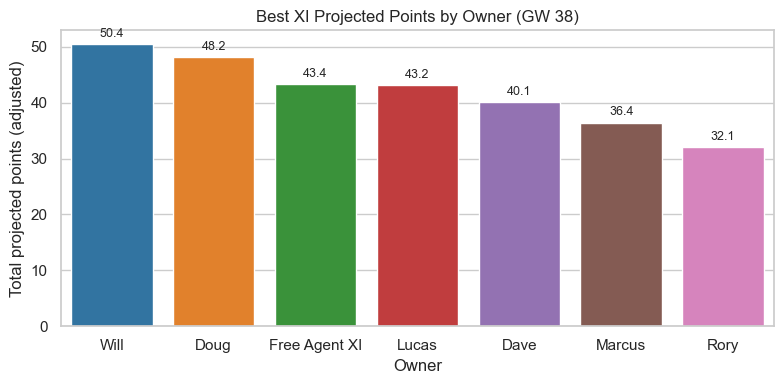

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_owner_summary = owner_summary.copy()

sns.barplot(
    data=plot_owner_summary,
    x='owner_name',
    y='predicted_points_adj_sum',
    hue='owner_name',
    legend=False,
    ax=ax,
    palette='tab10',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

ax.set_title(f'Best XI Projected Points by Owner (GW {latest_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Total projected points (adjusted)')
plt.xticks(rotation=0)
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'owner_best_xi_gw{latest_gw}.png', dpi=200)

## Shareable Plots

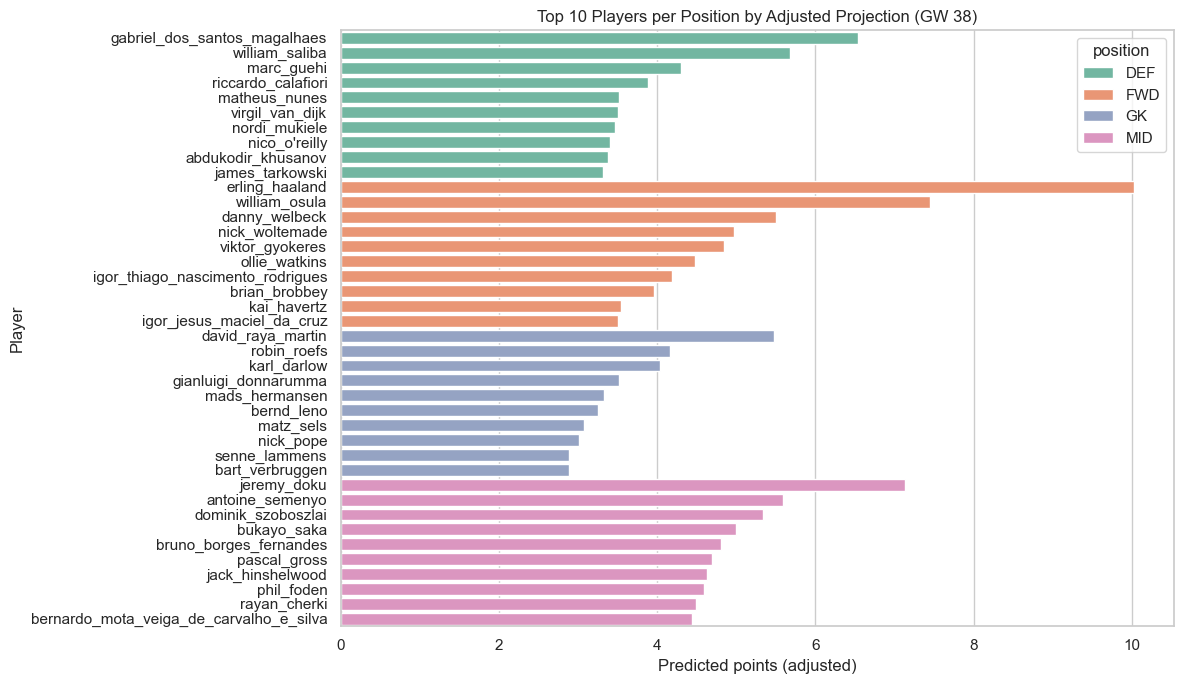

In [14]:
plot_df = (
    df_sorted
    .groupby('position', group_keys=False)
    .head(10)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_df.sort_values(['position', 'predicted_points_adj'], ascending=[True, False]),
    x='predicted_points_adj',
    y='full_name',
    hue='position',
    dodge=False,
    ax=ax,
    palette='Set2',
)
ax.set_title(f'Top 10 Players per Position by Adjusted Projection (GW {latest_gw})')
ax.set_xlabel('Predicted points (adjusted)')
ax.set_ylabel('Player')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'top10_by_position_gw{latest_gw}.png', dpi=200)

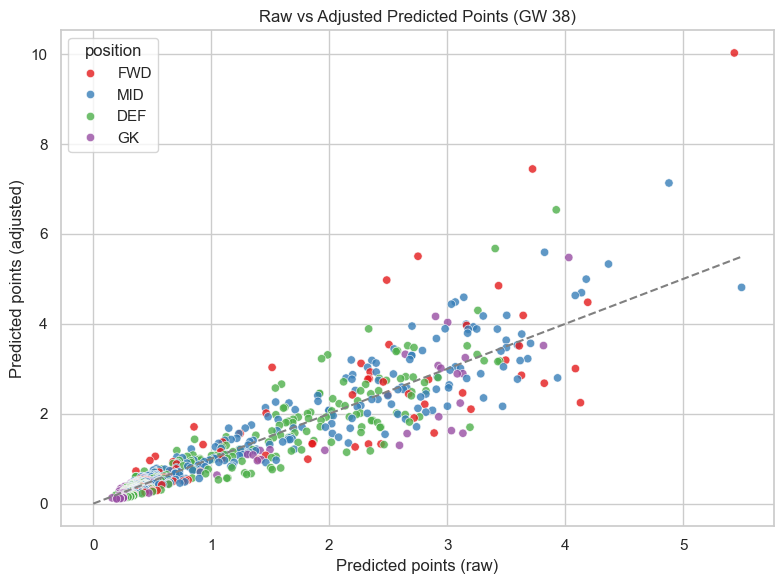

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_sorted,
    x='predicted_points',
    y='predicted_points_adj',
    hue='position',
    alpha=0.8,
    ax=ax,
    palette='Set1',
)
ax.plot([0, df_sorted['predicted_points'].max()], [0, df_sorted['predicted_points'].max()], linestyle='--', color='grey')
ax.set_title(f'Raw vs Adjusted Predicted Points (GW {latest_gw})')
ax.set_xlabel('Predicted points (raw)')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'raw_vs_adjusted_gw{latest_gw}.png', dpi=200)

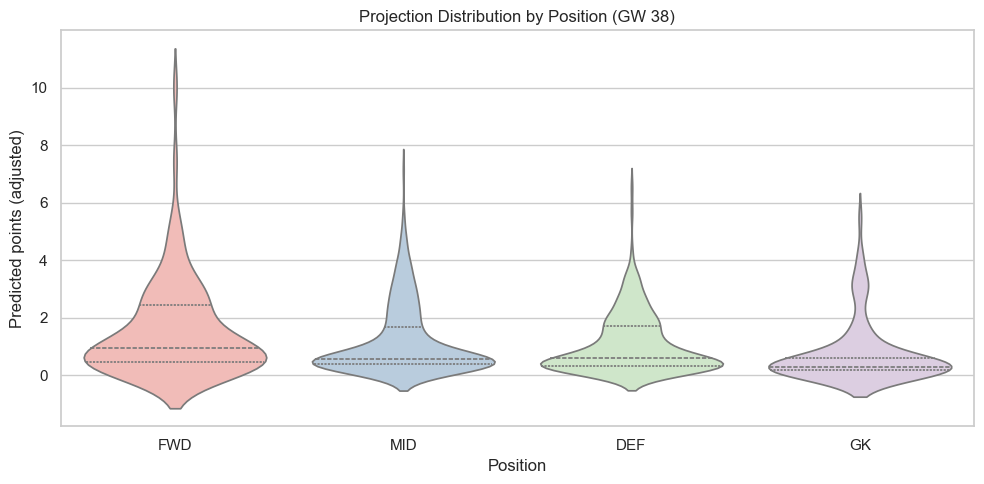

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_sorted,
    x='position',
    y='predicted_points_adj',
    inner='quartile',
    hue='position',
    legend=False,
    ax=ax,
    palette='Pastel1',
)
ax.set_title(f'Projection Distribution by Position (GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'distribution_by_position_gw{latest_gw}.png', dpi=200)

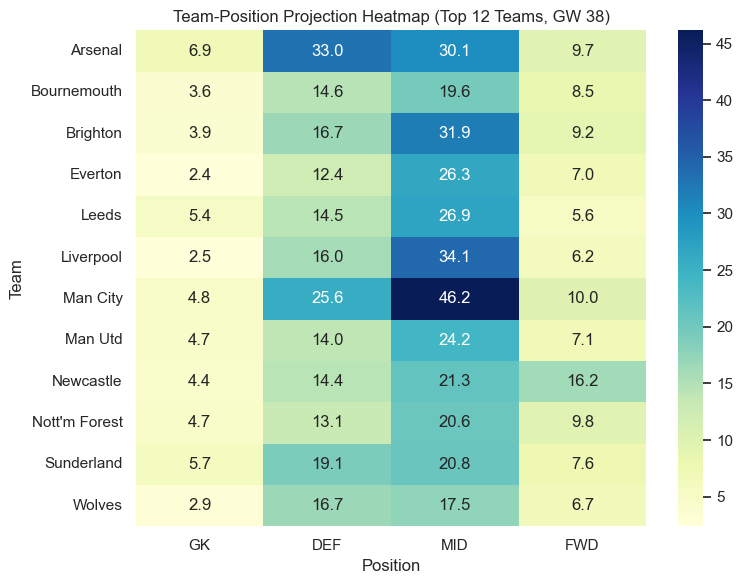

In [17]:
team_pos = (
    df_sorted
    .groupby(['team', 'position'], as_index=False)['predicted_points_adj']
    .sum()
)

team_total = team_pos.groupby('team', as_index=False)['predicted_points_adj'].sum()
top_teams = team_total.sort_values('predicted_points_adj', ascending=False).head(12)['team']
heat_df = team_pos[team_pos['team'].isin(top_teams)].pivot(index='team', columns='position', values='predicted_points_adj').fillna(0)
heat_df = heat_df[['GK', 'DEF', 'MID', 'FWD']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Team-Position Projection Heatmap (Top 12 Teams, GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Team')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'team_position_heatmap_gw{latest_gw}.png', dpi=200)

In [18]:
share_cols = ['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
share_table = df_sorted[share_cols].head(25).copy()
share_table

,full_name,position,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,erling_haaland,FWD,Man City,Doug,5.432718,10.027148,1.845696
1,william_osula,FWD,Newcastle,Will,3.722895,7.445791,2.000000
2,jeremy_doku,MID,Man City,Lucas,4.878831,7.133764,1.462187
3,gabriel_dos_santos_magalhaes,DEF,Arsenal,Will,3.923690,6.537303,1.666111
4,william_saliba,DEF,Arsenal,Lucas,3.406269,5.675221,1.666111
5,antoine_semenyo,MID,Man City,Will,3.824796,5.592568,1.462187
6,danny_welbeck,FWD,Brighton,Will,2.751983,5.503966,2.000000
7,david_raya_martin,GK,Arsenal,Dave,4.030086,5.476783,1.358974
8,dominik_szoboszlai,MID,Liverpool,Dave,4.366548,5.331112,1.220898
9,bukayo_saka,MID,Arsenal,Will,4.177743,4.994774,1.195568


In [19]:
if EXPORT_FIGURES:
    print(f'Saved figures to: {FIG_DIR.resolve()}')
else:
    print('Set EXPORT_FIGURES = True to save PNG charts for sharing.')

Set EXPORT_FIGURES = True to save PNG charts for sharing.


## Historical Backtest: Predicted vs Actual (All GWs)

In [20]:
import re
import sys
import requests

sys.path.append(str(Path('..').resolve()))
from wrangle_data_funcs import clean_name

predictions_dir = Path('predictions')
pred_files = sorted(predictions_dir.glob('predicted_gw[0-9]*.csv'))

gw_file_pairs = []
for file_path in pred_files:
    if file_path.name.endswith('_simple.csv'):
        continue
    match = re.search(r'predicted_gw(\d+)\.csv$', file_path.name)
    if match:
        gw_file_pairs.append((int(match.group(1)), file_path))

gw_file_pairs = sorted(gw_file_pairs, key=lambda x: x[0])
print(f'Found GW prediction files: {len(gw_file_pairs)}')

bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/', timeout=20).json()
name_by_element = {}
for elem in bootstrap['elements']:
    full_name = clean_name(f"{elem['first_name']}_{elem['second_name']}")
    name_by_element[elem['id']] = full_name

def load_actual_points_for_gw_from_api(gw):
    event_live = requests.get(f'https://fantasy.premierleague.com/api/event/{gw}/live/', timeout=20).json()
    rows = []
    for item in event_live.get('elements', []):
        element_id = item.get('id')
        full_name = name_by_element.get(element_id)
        if full_name is None:
            continue
        total_points = item.get('stats', {}).get('total_points', np.nan)
        rows.append({'full_name': full_name, 'actual_points': total_points})

    actual_gw_df = pd.DataFrame(rows)
    if actual_gw_df.empty:
        raise ValueError(f'No actual rows returned from FPL API for GW {gw}')

    return actual_gw_df

backtest_frames = []
skipped_gws = []
for gw, file_path in gw_file_pairs:
    pred_gw_df = pd.read_csv(file_path)
    if 'predicted_points_adj' not in pred_gw_df.columns:
        pred_gw_df['predicted_points_adj'] = pred_gw_df['predicted_points']

    try:
        actual_gw_df = load_actual_points_for_gw_from_api(gw)
    except Exception as exc:
        skipped_gws.append((gw, str(exc)))
        continue

    merged = pred_gw_df.merge(actual_gw_df, on='full_name', how='inner')
    if merged.empty:
        skipped_gws.append((gw, 'No name overlap between prediction and actual files'))
        continue

    merged['gw'] = gw
    backtest_frames.append(
        merged[['gw', 'full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'actual_points']]
    )

backtest_df = pd.concat(backtest_frames, ignore_index=True) if backtest_frames else pd.DataFrame()
print(f'Total merged player-GW rows: {len(backtest_df):,}')
if skipped_gws:
    print(f'Skipped GWs: {[gw for gw, _ in skipped_gws]}')

if not backtest_df.empty:
    backtest_df['error_raw'] = backtest_df['predicted_points'] - backtest_df['actual_points']
    backtest_df['error_adj'] = backtest_df['predicted_points_adj'] - backtest_df['actual_points']
    backtest_df['abs_error_raw'] = backtest_df['error_raw'].abs()
    backtest_df['abs_error_adj'] = backtest_df['error_adj'].abs()

backtest_df.head()

Found GW prediction files: 37
Total merged player-GW rows: 27,665
Skipped GWs: [38]


,gw,full_name,position,team,predicted_points,predicted_points_adj,actual_points,error_raw,error_adj,abs_error_raw,abs_error_adj
0,2,aaron_anselmino,DEF,Chelsea,0.739413,6.059800,0,0.739413,6.059800,0.739413,6.059800
1,2,aaron_hickey,DEF,Brentford,0.729099,0.975531,1,-0.270901,-0.024469,0.270901,0.024469
2,2,aaron_ramsdale,GK,Newcastle,0.865016,2.491246,0,0.865016,2.491246,0.865016,2.491246
3,2,aaron_ramsey,MID,Burnley,0.665792,0.547374,0,0.665792,0.547374,0.665792,0.547374
4,2,aaron_wan_bissaka,DEF,West Ham,2.558778,1.878468,0,2.558778,1.878468,2.558778,1.878468


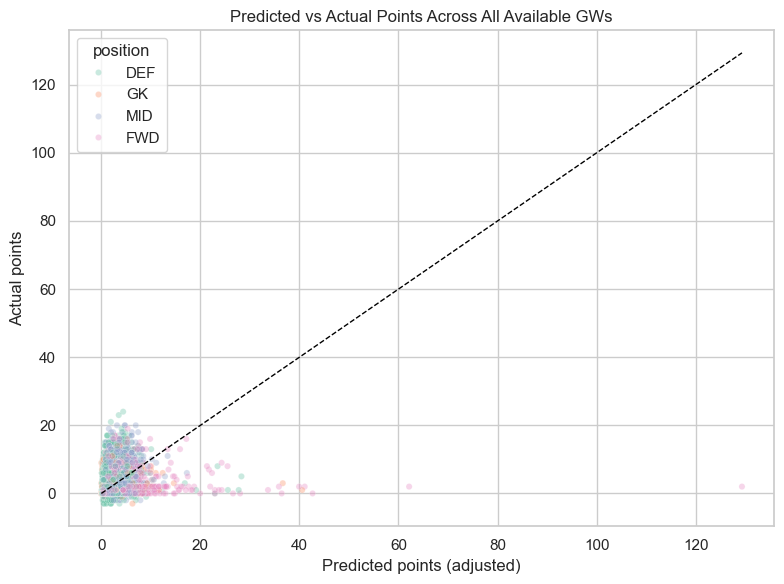

In [21]:
if backtest_df.empty:
    print('No backtest rows available. Check BACKTEST_YEAR and prediction files.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=backtest_df,
        x='predicted_points_adj',
        y='actual_points',
        hue='position',
        alpha=0.35,
        s=20,
        ax=ax,
        palette='Set2',
    )

    max_axis = max(backtest_df['predicted_points_adj'].max(), backtest_df['actual_points'].max(), 1)
    ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Predicted vs Actual Points Across All Available GWs')
    ax.set_xlabel('Predicted points (adjusted)')
    ax.set_ylabel('Actual points')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'pred_vs_actual_all_gws.png', dpi=200)

,gw,mae_raw,mae_adj,rmse_raw,rmse_adj,corr_adj,n_players
0,2,1.398942,3.031277,2.290521,7.130428,0.128786,688
1,3,1.367993,1.751509,2.044060,3.369252,0.237116,704
2,4,1.374622,1.598399,2.056003,2.816350,0.386894,711
3,5,1.274219,1.544102,1.905574,2.917723,0.316065,739
4,6,1.233781,1.430650,1.938378,2.333200,0.442224,740
5,7,1.288138,1.448172,1.965947,2.374257,0.428807,741
6,8,1.335244,1.444678,2.145013,2.361295,0.472751,742
7,9,1.294102,1.432641,2.076107,3.082161,0.299649,744
8,10,1.300248,1.452354,1.942554,2.234027,0.480215,745
9,11,1.348842,1.476944,2.078492,2.306451,0.465562,746


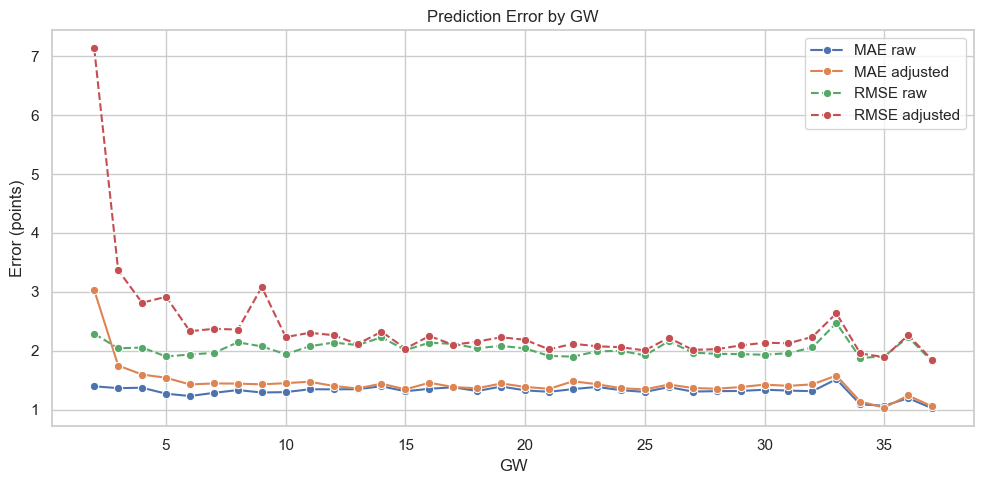

In [22]:
if backtest_df.empty:
    print('No backtest rows available. Skipping GW metric plots.')
else:
    gw_metrics = (
        backtest_df.groupby('gw', as_index=False)
        .agg(
            mae_raw=('abs_error_raw', 'mean'),
            mae_adj=('abs_error_adj', 'mean'),
            rmse_raw=('error_raw', lambda x: np.sqrt(np.mean(np.square(x)))),
            rmse_adj=('error_adj', lambda x: np.sqrt(np.mean(np.square(x)))),
            corr_adj=('predicted_points_adj', lambda x: x.corr(backtest_df.loc[x.index, 'actual_points'])),
            n_players=('full_name', 'count'),
        )
    )

    display(gw_metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=gw_metrics, x='gw', y='mae_raw', marker='o', label='MAE raw', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='mae_adj', marker='o', label='MAE adjusted', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_raw', marker='o', label='RMSE raw', ax=ax, linestyle='--')
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_adj', marker='o', label='RMSE adjusted', ax=ax, linestyle='--')
    ax.set_title('Prediction Error by GW')
    ax.set_xlabel('GW')
    ax.set_ylabel('Error (points)')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'prediction_error_by_gw.png', dpi=200)

### What Is corr_adj?

`corr_adj` is the Pearson correlation between `predicted_points_adj` and `actual_points` within each GW.

- `corr_adj` near `1.0`: your model ranked players very well that week.
- `corr_adj` near `0.0`: weak relationship between predictions and outcomes.
- `corr_adj` below `0.0`: rankings were directionally wrong that week.

This is most useful for judging ranking quality, not absolute error size.

,gw,corr_adj
0,2,0.128786
1,3,0.237116
2,4,0.386894
3,5,0.316065
4,6,0.442224
5,7,0.428807
6,8,0.472751
7,9,0.299649
8,10,0.480215
9,11,0.465562


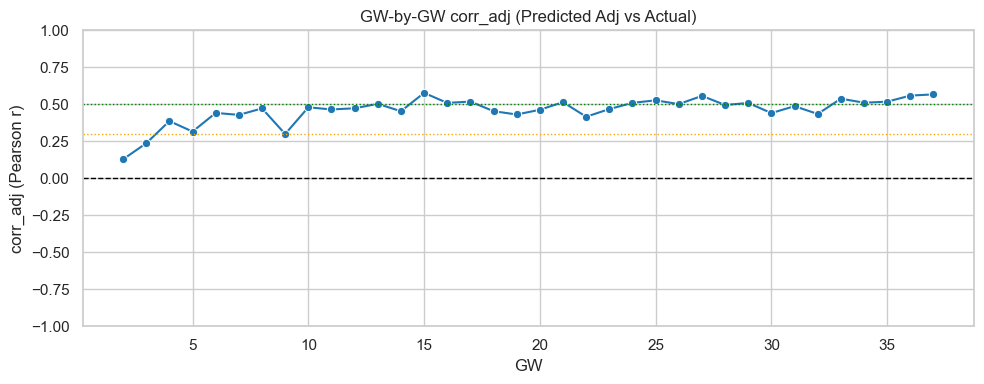

In [23]:
if backtest_df.empty:
    print('No backtest rows available. Skipping corr_adj plot.')
else:
    corr_plot_df = gw_metrics[['gw', 'corr_adj']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=corr_plot_df, x='gw', y='corr_adj', marker='o', ax=ax, color='#1f77b4')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='green', linestyle=':', linewidth=1)
    ax.axhline(0.3, color='orange', linestyle=':', linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title('GW-by-GW corr_adj (Predicted Adj vs Actual)')
    ax.set_xlabel('GW')
    ax.set_ylabel('corr_adj (Pearson r)')
    plt.tight_layout()

    display(corr_plot_df)

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'corr_adj_by_gw.png', dpi=200)